<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Generate_Heatmaps_Top20_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

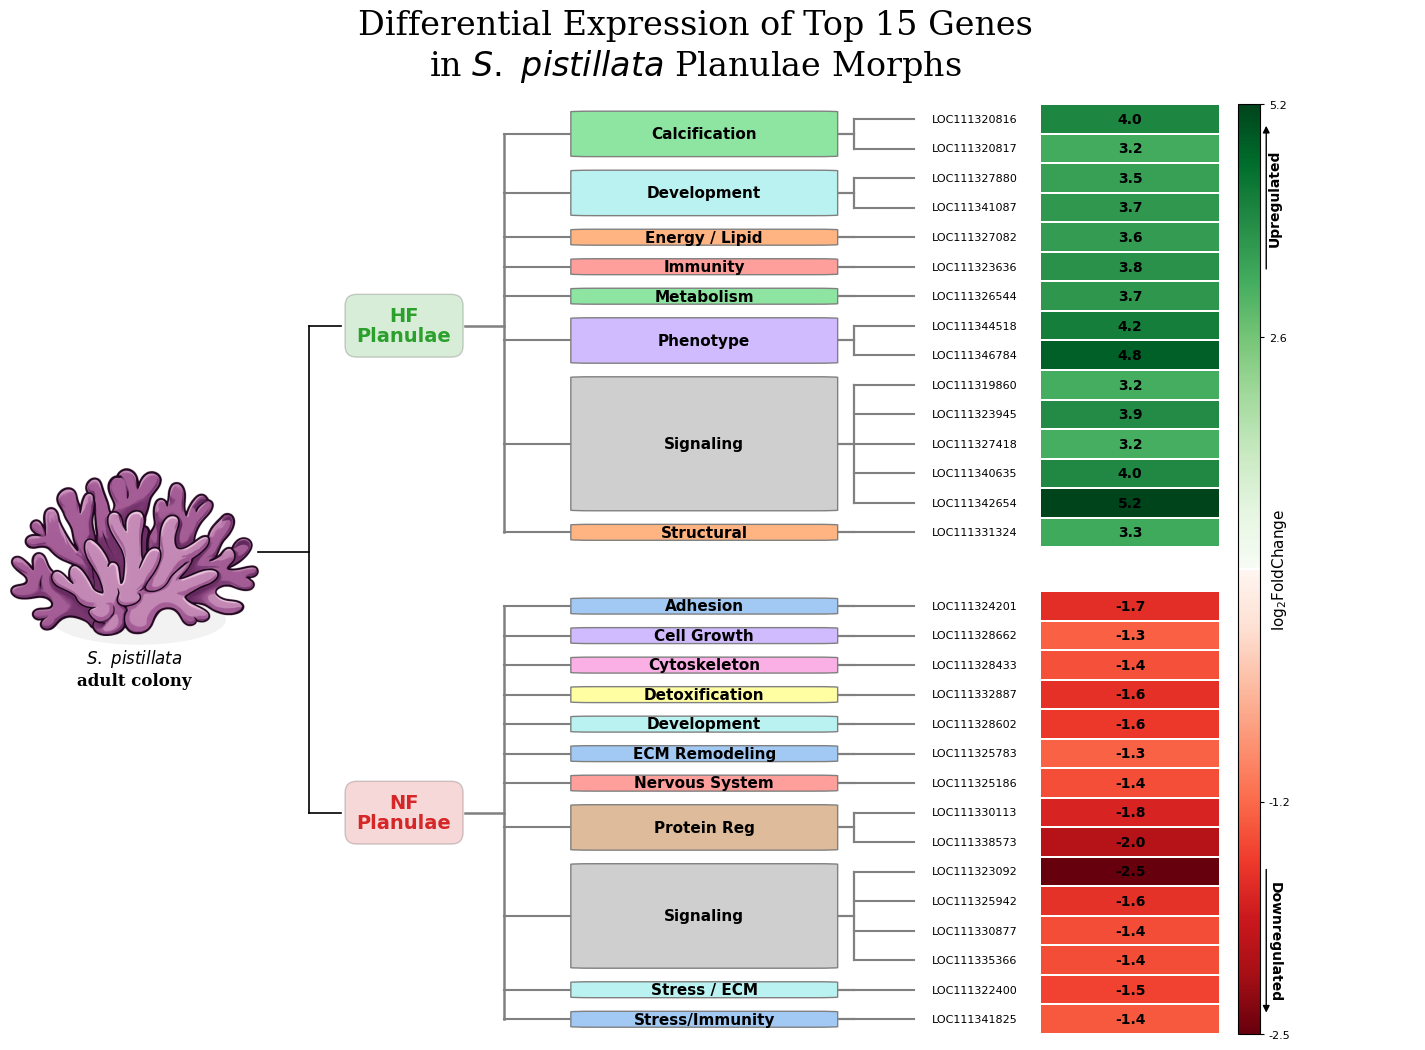

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.image as mpimg

from matplotlib.patches import FancyBboxPatch, Ellipse
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter

# ==================================================
# 0. DATA LOADING AND PREPROCESSING
# ==================================================
df_genes = pd.read_csv("/content/Categorized_Gene_Table_HF_NF_with_LFC_no_unknown.csv")

plot_df_hf_all = df_genes[df_genes["Morph"] == "HF"].copy()
plot_df_nf_all = df_genes[df_genes["Morph"] == "NF"].copy()

plot_df_hf = plot_df_hf_all.sort_values(by="LFC", ascending=False).head(15)
plot_df_nf = plot_df_nf_all.sort_values(by="LFC", ascending=True).head(15)

data_tree_hf = {"HF": {}}
data_tree_nf = {"NF": {}}

flat_genes_hf, flat_genes_nf = [], []
y_positions_hf, y_positions_nf = {}, {}

current_y_hf = 0
for category in sorted(plot_df_hf["Category"].unique()):
    genes_in_category = plot_df_hf[plot_df_hf["Category"] == category].sort_values(by="Gene Symbol")
    data_tree_hf["HF"][category] = []
    for _, row in genes_in_category.iterrows():
        gene_symbol = row["Gene Symbol"]
        lfc = row["LFC"]
        data_tree_hf["HF"][category].append((gene_symbol, lfc))
        flat_genes_hf.append(gene_symbol)
        y_positions_hf[gene_symbol] = current_y_hf + 0.5
        current_y_hf += 1

current_y_nf = 0
for category in sorted(plot_df_nf["Category"].unique()):
    genes_in_category = plot_df_nf[plot_df_nf["Category"] == category].sort_values(by="Gene Symbol")
    data_tree_nf["NF"][category] = []
    for _, row in genes_in_category.iterrows():
        gene_symbol = row["Gene Symbol"]
        lfc = row["LFC"]
        data_tree_nf["NF"][category].append((gene_symbol, lfc))
        flat_genes_nf.append(gene_symbol)
        y_positions_nf[gene_symbol] = current_y_nf + 0.5
        current_y_nf += 1

# ==================================================
# 1. COLORS
# ==================================================
morph_colors = {"HF": "#2ca02c", "NF": "#d62728"}

all_categories = sorted(df_genes["Category"].unique())
PASTELS = sns.color_palette("pastel", len(all_categories))
category_colors = dict(zip(all_categories, PASTELS))

# ==================================================
# 2. FIGURE SETUP (less dead space)
# ==================================================
n_rows = max(len(flat_genes_hf), len(flat_genes_nf))
fig_h = 7 + 0.28 * n_rows

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, fig_h),
    gridspec_kw={"width_ratios": [11, 1], "wspace": 0.01, "hspace": 0.10},
    sharey="row"
)
fig.subplots_adjust(top=0.90, bottom=0.07)

# ==================================================
# 2A. LAYOUT CONTROLS
# ==================================================
x_morph = 0.11
x_trunk = 0.20

x_cat = 0.38
cat_w = 0.20
cat_right = x_cat + cat_w / 2

CAT_TO_FORK  = 0.035
FORK_TO_GENE = 0.070

x_fork = cat_right + CAT_TO_FORK
x_gene_label = x_fork + FORK_TO_GENE
gene_line_gap = 0.016

line_z = 1
box_z  = 3
text_z = 4

FLOW_LEFT  = 0.07
FLOW_RIGHT = 0.70
FLOW_WIDTH = FLOW_RIGHT - FLOW_LEFT

HEAT_WIDTH = 0.10

def set_ax_pos(ax, left=None, width=None, bottom=None, height=None):
    p = ax.get_position()
    ax.set_position([
        p.x0 if left   is None else left,
        p.y0 if bottom is None else bottom,
        p.width if width is None else width,
        p.height if height is None else height
    ])

set_ax_pos(axes[0, 0], left=FLOW_LEFT, width=FLOW_WIDTH)
set_ax_pos(axes[1, 0], left=FLOW_LEFT, width=FLOW_WIDTH)

# ==================================================
# 3. SHARED COLORMAP + NORM
# ==================================================
hf_max_lfc = float(plot_df_hf["LFC"].max())
nf_min_lfc = float(plot_df_nf["LFC"].min())

norm = TwoSlopeNorm(vmin=nf_min_lfc, vcenter=0.0, vmax=hf_max_lfc)

c_neg = plt.get_cmap("Reds_r")(np.linspace(0.0, 1.0, 256))
c_pos = plt.get_cmap("Greens")(np.linspace(0.0, 1.0, 256))
white = np.array([[1, 1, 1, 1]])
combined = np.vstack([c_neg, white, c_pos])
cmap_shared = LinearSegmentedColormap.from_list("RedWhiteGreen", combined, N=513)

# ==================================================
# 4. FLOW DIAGRAM (returns morph text artist)
# ==================================================
def draw_flow(ax, data_tree, y_pos, morph):
    ax.axis("off")

    cats = data_tree[morph]
    all_genes = [g[0] for v in cats.values() for g in v]
    ys_all = [y_pos[g] for g in all_genes]
    morph_y = float(np.mean(ys_all)) if ys_all else 0.5

    # Trunk span based on category midpoints
    cat_mids = []
    for _cat, genes in cats.items():
        ys = [y_pos[g[0]] for g in genes]
        if ys:
            cat_mids.append((min(ys) + max(ys)) / 2)

    trunk_ymin = min(cat_mids) if cat_mids else morph_y - 1
    trunk_ymax = max(cat_mids) if cat_mids else morph_y + 1

    # Morph label
    t_morph = ax.text(
        x_morph, morph_y, f"{morph}\nPlanulae",
        ha="center", va="center",
        fontsize=14, fontweight="bold", linespacing=1.1,
        bbox=dict(boxstyle="round,pad=0.6", fc=morph_colors[morph], ec="black", alpha=0.18),
        color=morph_colors[morph],
        zorder=text_z
    )

    # --- FIX: connector from morph box RIGHT edge to trunk (restores missing segment) ---
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox = t_morph.get_bbox_patch().get_window_extent(renderer=renderer)  # display coords

    pad_px = 3
    x_start_disp = bbox.x1 + pad_px
    y_start_disp = (bbox.y0 + bbox.y1) / 2
    x_start_data, _ = ax.transData.inverted().transform((x_start_disp, y_start_disp))

    ax.plot([x_start_data, x_trunk], [morph_y, morph_y],
            color="gray", lw=1.8, zorder=line_z)

    # trunk
    ax.plot([x_trunk, x_trunk], [trunk_ymin, trunk_ymax],
            color="gray", lw=1.8, zorder=line_z)

    for cat, genes in cats.items():
        ys_in_cat = [y_pos[g[0]] for g in genes]
        if not ys_in_cat:
            continue

        min_y = min(ys_in_cat)
        max_y = max(ys_in_cat)
        cat_y = (min_y + max_y) / 2

        y_padding = 0.5
        box_bottom = min_y - y_padding / 2
        box_height = (max_y - min_y) + y_padding

        # trunk → category
        ax.plot([x_trunk, x_cat - cat_w / 2], [cat_y, cat_y],
                color="gray", lw=1.5, zorder=line_z)

        rect = FancyBboxPatch(
            (x_cat - cat_w / 2, box_bottom),
            cat_w, box_height,
            boxstyle="round,pad=0.02",
            ec="gray", fc=category_colors[cat],
            zorder=box_z
        )
        ax.add_patch(rect)

        ax.text(
            x_cat, cat_y, cat,
            ha="center", va="center",
            fontsize=11, fontweight="bold", color="black",
            zorder=text_z
        )

        # category → fork + fork vertical
        ax.plot([x_cat + cat_w / 2, x_fork], [cat_y, cat_y],
                color="gray", lw=1.6, zorder=line_z)
        ax.plot([x_fork, x_fork], [min_y, max_y],
                color="gray", lw=1.6, zorder=line_z)

        for gene_symbol, _lfc in genes:
            y_gene = y_pos[gene_symbol]
            ax.plot([x_fork, x_gene_label - gene_line_gap], [y_gene, y_gene],
                    color="gray", lw=1.5, zorder=line_z)
            ax.text(
                x_gene_label, y_gene, gene_symbol,
                ha="left", va="center",
                fontsize=8, color="black",
                zorder=text_z,
                bbox=dict(fc="white", ec="none", pad=0.20, alpha=0.95)
            )

    ax.set_xlim(0, 1.02)
    return t_morph

# ==================================================
# 5. DRAW FLOW PANELS
# ==================================================
t_hf = draw_flow(axes[0, 0], data_tree_hf, y_positions_hf, "HF")
t_nf = draw_flow(axes[1, 0], data_tree_nf, y_positions_nf, "NF")

# ==================================================
# 5A. AUTO-PLACE HEATMAPS NEXT TO GENE LABELS
# ==================================================
fig.canvas.draw()

def gene_label_right_edge_fig(ax_flow, x_text_data, pad_fig=0.004):
    x_disp, _ = ax_flow.transData.transform((x_text_data, 0))
    x_fig, _ = fig.transFigure.inverted().transform((x_disp, 0))
    return x_fig + pad_fig

HEAT_GAP_FIG = 0.06
heat_left = gene_label_right_edge_fig(axes[0, 0], x_gene_label, pad_fig=HEAT_GAP_FIG)
heat_left = min(0.92, heat_left)

set_ax_pos(axes[0, 1], left=heat_left, width=HEAT_WIDTH)
set_ax_pos(axes[1, 1], left=heat_left, width=HEAT_WIDTH)

# ==================================================
# 6. HEATMAPS (remove 'Gene Symbol')
# ==================================================
CELL_GAP = 0.22

hf_heat = plot_df_hf.set_index("Gene Symbol").reindex(flat_genes_hf)[["LFC"]]
hf_heat.index.name = None  # remove "Gene Symbol"

sns.heatmap(
    hf_heat, ax=axes[0, 1],
    cmap=cmap_shared, norm=norm,
    annot=True, fmt=".1f",
    linewidths=CELL_GAP, linecolor="white",
    cbar=False, xticklabels=False, yticklabels=False,
    annot_kws={"color": "black", "weight": "bold"},
)
axes[0, 1].tick_params(left=False, bottom=False)
axes[0, 1].set_ylim(axes[0, 0].get_ylim())
axes[0, 1].set_ylabel("")
axes[0, 1].yaxis.label.set_visible(False)

nf_heat = plot_df_nf.set_index("Gene Symbol").reindex(flat_genes_nf)[["LFC"]]
nf_heat.index.name = None  # remove "Gene Symbol"

sns.heatmap(
    nf_heat, ax=axes[1, 1],
    cmap=cmap_shared, norm=norm,
    annot=True, fmt=".1f",
    linewidths=CELL_GAP, linecolor="white",
    cbar=False, xticklabels=False, yticklabels=False,
    annot_kws={"color": "black", "weight": "bold"},
)
axes[1, 1].tick_params(left=False, bottom=False)
axes[1, 1].set_ylim(axes[1, 0].get_ylim())
axes[1, 1].set_ylabel("")
axes[1, 1].yaxis.label.set_visible(False)

# ==================================================
# 7. CORAL IMAGE
# ==================================================
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

# Morph center in figure coords (for coral placement only)
hf_center = t_hf.get_window_extent(renderer=renderer).get_points().mean(axis=0)
nf_center = t_nf.get_window_extent(renderer=renderer).get_points().mean(axis=0)
hx0, hy0 = fig.transFigure.inverted().transform(hf_center)
nx0, ny0 = fig.transFigure.inverted().transform(nf_center)

root_w = 0.10
root_h = 0.05

morph_left_x = min(hx0, nx0)

# Move coral to the RIGHT by decreasing the subtraction (try 0.07 -> 0.04 if needed)
root_x = max(-0.10, morph_left_x - root_w - 0.10)
root_y = 0.50 - root_h / 2

img = mpimg.imread("S_pistillata.png")

# --- Auto-crop image to content (handles transparency or white background) ---
if img.ndim == 3 and img.shape[2] == 4:
    # RGBA: crop by alpha > threshold
    alpha = img[:, :, 3]
    mask = alpha > 0.05
else:
    # RGB: crop by "not near white"
    rgb = img[:, :, :3]
    mask = np.any(rgb < 0.98, axis=2)

ys, xs = np.where(mask)
if len(xs) > 0 and len(ys) > 0:
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    img = img[y0:y1, x0:x1]
scale = 3

img_left   = root_x - (root_w * (scale - 1) / 2)
img_bottom = root_y - (root_h * (scale - 1) / 2)
img_w      = root_w * scale
img_h      = root_h * scale

ax_img = fig.add_axes([img_left, img_bottom, img_w, img_h], zorder=30)
ax_img.imshow(img)
ax_img.axis("off")

fig.canvas.draw()
img_pos = ax_img.get_position()

shadow = Ellipse(
    (img_pos.x0 + img_pos.width * 0.52, img_pos.y0 + img_pos.height * 0.10),
    width=img_pos.width * 0.7,
    height=img_pos.height * 0.30,
    transform=fig.transFigure,
    facecolor="black", edgecolor="none",
    alpha=0.05, zorder=29
)
fig.add_artist(shadow)

fig.text(
    root_x + root_w / 2,
    img_bottom - 0.01,
    r"$\it{S.\ pistillata}$" + "\n" + "adult colony",
    ha="center", va="top",
    fontsize=12, fontfamily="serif", fontweight="bold",
    zorder=31
)

# ==================================================
# 7B. CONNECTOR (snap to morph BOX edges)
# ==================================================
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

# IMPORTANT: use bbox patch (rounded box), not text extent
hf_box = t_hf.get_bbox_patch().get_window_extent(renderer=renderer)
nf_box = t_nf.get_bbox_patch().get_window_extent(renderer=renderer)

hf_left_fig, hf_y_fig = fig.transFigure.inverted().transform((hf_box.x0, (hf_box.y0 + hf_box.y1) / 2))
nf_left_fig, nf_y_fig = fig.transFigure.inverted().transform((nf_box.x0, (nf_box.y0 + nf_box.y1) / 2))

# Coral anchor: right-center of coral image
coral_x = img_pos.x1
coral_y = img_pos.y0 + img_pos.height / 2

# Trunk X between coral and morph boxes
TRUNK_GAP_FROM_MORPH = 0.02
trunk_x = min(hf_left_fig, nf_left_fig) - TRUNK_GAP_FROM_MORPH
trunk_x = max(trunk_x, coral_x + 0.02)

wire_color = "black"
wire_lw = 1.2
z = 50

# coral → trunk
fig.add_artist(Line2D([coral_x, trunk_x], [coral_y, coral_y],
                      transform=fig.transFigure, color=wire_color, lw=wire_lw, zorder=z))

# trunk vertical
y_top = max(hf_y_fig, nf_y_fig)
y_bot = min(hf_y_fig, nf_y_fig)
fig.add_artist(Line2D([trunk_x, trunk_x], [y_bot, y_top],
                      transform=fig.transFigure, color=wire_color, lw=wire_lw, zorder=z))

# branches to morph box LEFT edges (with tiny gap so it doesn't overlap border)
EDGE_GAP = 0.002
fig.add_artist(Line2D([trunk_x, hf_left_fig - EDGE_GAP], [hf_y_fig, hf_y_fig],
                      transform=fig.transFigure, color=wire_color, lw=wire_lw, zorder=z))
fig.add_artist(Line2D([trunk_x, nf_left_fig - EDGE_GAP], [nf_y_fig, nf_y_fig],
                      transform=fig.transFigure, color=wire_color, lw=wire_lw, zorder=z))

# ==================================================
# 8. SINGLE SHARED LEGEND
# ==================================================
fig.canvas.draw()
pos_hf = axes[0, 1].get_position()
pos_nf = axes[1, 1].get_position()

cbar_left   = pos_hf.x1 + 0.010
cbar_bottom = pos_nf.y0
cbar_height = pos_hf.y1 - pos_nf.y0
cbar_width  = 0.012

cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])

sm = ScalarMappable(norm=norm, cmap=cmap_shared)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax)

cb.ax.tick_params(labelsize=8, length=3)
ticks = [nf_min_lfc, nf_min_lfc/2, hf_max_lfc/2, hf_max_lfc]
cb.set_ticks(ticks)

cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}"))

# Put the label on the RIGHT side of the colorbar (cleaner with your arrows)
cb.ax.yaxis.set_label_position("right")
cb.set_label(r"log$_2$FoldChange",
             fontsize=11,
             #fontweight="bold",
             rotation=90,
             labelpad=-15
)

# Upregulated / Downregulated annotations
cax.annotate("", xy=(1.30, 0.98), xycoords="axes fraction",
             xytext=(1.30, 0.82), textcoords="axes fraction",
             arrowprops=dict(arrowstyle="-|>", lw=1.0, color="black"))
cax.text(1.36, 0.90, "Upregulated", transform=cax.transAxes,
         rotation=90, ha="left", va="center", fontsize=10, fontweight="bold")

cax.annotate("", xy=(1.30, 0.02), xycoords="axes fraction",
             xytext=(1.30, 0.18), textcoords="axes fraction",
             arrowprops=dict(arrowstyle="-|>", lw=1.0, color="black"))
cax.text(1.36, 0.10, "Downregulated", transform=cax.transAxes,
         rotation=270, ha="left", va="center", fontsize=10, fontweight="bold")

# ==================================================
# 9. TITLE (top middle)
# ==================================================
fig.suptitle(
    r"Differential Expression of Top 15 Genes" + "\n" + r"in $\it{S.\ pistillata}$ Planulae Morphs",
    fontsize=24,
    fontfamily="serif",
    x=0.3, ha="center",
    y=0.985
)



# Save (recommended for publication; removes residual whitespace)
plt.savefig("Flow_Heatmap_FINAL.png", dpi=600, bbox_inches="tight", pad_inches=0.10)
plt.savefig("Flow_Heatmap_FINAL.tiff", dpi=600, bbox_inches="tight", pad_inches=0.10)
plt.savefig("Flow_Heatmap_FINAL.pdf", dpi=600, bbox_inches="tight", pad_inches=0.10)
plt.savefig("Flow_Heatmap_FINAL.svg", dpi=600, bbox_inches="tight", pad_inches=0.10)

plt.show()